# 01 — Data Exploration and Cleaning

## Project: Online Shoppers Purchase Intention

This notebook is used to:

1. load the dataset;
2. understand its structure;
3. check data quality;
4. perform basic cleaning;
5. complete a first exploration;
6. export a clean dataset for the next stage.

The code is intentionally simple and easy to understand.

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


## 2. Load the Dataset

In [2]:
from pathlib import Path

# The notebook can be run from the repository root or from the notebooks folder.
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir

file_path = project_root / "data" / "raw" / "online_shoppers_intention.csv"

df = pd.read_csv(file_path)

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Understand the Dataset Structure

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 12330
Number of columns: 18


In [4]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

## 4. Check Data Quality

### 4.1 Missing Values

In [6]:
missing_values = df.isnull().sum()

missing_values

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [7]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


### 4.2 Identical Rows

In [8]:
duplicate_rows = df.duplicated().sum()

print("Number of fully identical rows:", duplicate_rows)

Number of fully identical rows: 125


**Decision:** the identical rows are not automatically removed.

The dataset does not contain a unique session identifier. Two different sessions may therefore contain exactly the same values. Removing them without evidence could distort the analysis.

### 4.3 Summary Statistics

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


### 4.4 Categorical Values

In [10]:
print("Months:", df["Month"].unique())
print()
print("Visitor types:", df["VisitorType"].unique())
print()
print("Weekend:", df["Weekend"].unique())
print()
print("Revenue:", df["Revenue"].unique())

Months: ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']

Visitor types: ['Returning_Visitor' 'New_Visitor' 'Other']

Weekend: [False  True]

Revenue: [False  True]


### 4.5 Check Negative Values

In [11]:
numeric_columns = df.select_dtypes(include="number").columns

negative_values = (df[numeric_columns] < 0).sum()

negative_values

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
dtype: int64

## 5. Basic Data Cleaning

In [12]:
# Create a copy to keep the original dataset unchanged
df_clean = df.copy()

### 5.1 Standardise Column Names

In [13]:
df_clean.columns = df_clean.columns.str.strip().str.lower()

df_clean.columns.tolist()

['administrative',
 'administrative_duration',
 'informational',
 'informational_duration',
 'productrelated',
 'productrelated_duration',
 'bouncerates',
 'exitrates',
 'pagevalues',
 'specialday',
 'month',
 'operatingsystems',
 'browser',
 'region',
 'traffictype',
 'visitortype',
 'weekend',
 'revenue']

### 5.2 Standardise Text Values

In [14]:
# Remove unnecessary spaces
df_clean["month"] = df_clean["month"].str.strip()
df_clean["visitortype"] = df_clean["visitortype"].str.strip()

# Use the same short format for all months
df_clean["month"] = df_clean["month"].replace({"June": "Jun"})

# Make visitor-type labels easier to read
df_clean["visitortype"] = df_clean["visitortype"].str.replace("_", " ", regex=False)

print(df_clean["month"].unique())
print(df_clean["visitortype"].unique())

['Feb' 'Mar' 'May' 'Oct' 'Jun' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
['Returning Visitor' 'New Visitor' 'Other']


### 5.3 Add the Month Number

In [15]:
month_order = {
    "Jan": 1,
    "Feb": 2,
    "Mar": 3,
    "Apr": 4,
    "May": 5,
    "Jun": 6,
    "Jul": 7,
    "Aug": 8,
    "Sep": 9,
    "Oct": 10,
    "Nov": 11,
    "Dec": 12
}

df_clean["month_number"] = df_clean["month"].map(month_order)

df_clean[["month", "month_number"]].drop_duplicates().sort_values("month_number")

,month,month_number
0,Feb,2
184,Mar,3
2091,May,5
5456,Jun,6
5460,Jul,7
5462,Aug,8
5468,Sep,9
5455,Oct,10
5463,Nov,11
7982,Dec,12


### 5.4 Convert Boolean Columns to 0 and 1

In [16]:
df_clean["weekend"] = df_clean["weekend"].astype(int)
df_clean["revenue"] = df_clean["revenue"].astype(int)

df_clean[["weekend", "revenue"]].head()

,weekend,revenue
0,0,0
1,0,0
2,0,0
3,0,0
4,1,0


### 5.5 Final Check

In [17]:
print("Final dimensions:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print()
print(df_clean.dtypes)

Final dimensions: (12330, 19)
Missing values: 0

administrative               int64
administrative_duration    float64
informational                int64
informational_duration     float64
productrelated               int64
productrelated_duration    float64
bouncerates                float64
exitrates                  float64
pagevalues                 float64
specialday                 float64
month                       object
operatingsystems             int64
browser                      int64
region                       int64
traffictype                  int64
visitortype                 object
weekend                      int64
revenue                      int64
month_number                 int64
dtype: object


## 6. Initial Data Exploration

### 6.1 Purchase Distribution

In [18]:
purchase_counts = df_clean["revenue"].value_counts().sort_index()

purchase_counts.index = ["No Purchase", "Purchase"]
purchase_counts

No Purchase    10422
Purchase        1908
Name: count, dtype: int64

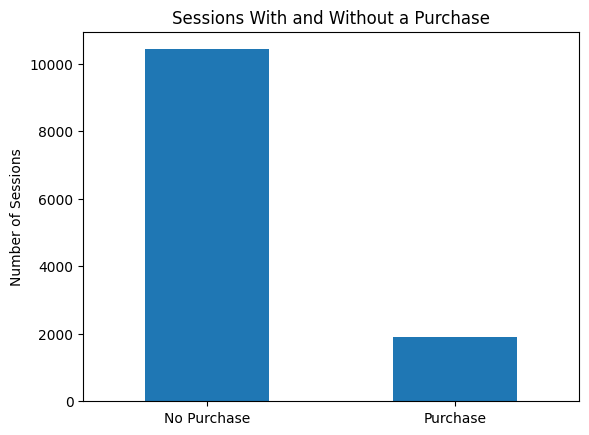

In [19]:
purchase_counts.plot(kind="bar")

plt.title("Sessions With and Without a Purchase")
plt.xlabel("")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)
plt.show()

### 6.2 Overall Conversion Rate

In [20]:
conversion_rate = df_clean["revenue"].mean() * 100

print("Overall conversion rate:", round(conversion_rate, 2), "%")

Overall conversion rate: 15.47 %


### 6.3 Conversion Rate by Visitor Type

In [21]:
conversion_by_visitor = (
    df_clean.groupby("visitortype")["revenue"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

conversion_by_visitor

visitortype
New Visitor          24.911452
Other                18.823529
Returning Visitor    13.932329
Name: revenue, dtype: float64

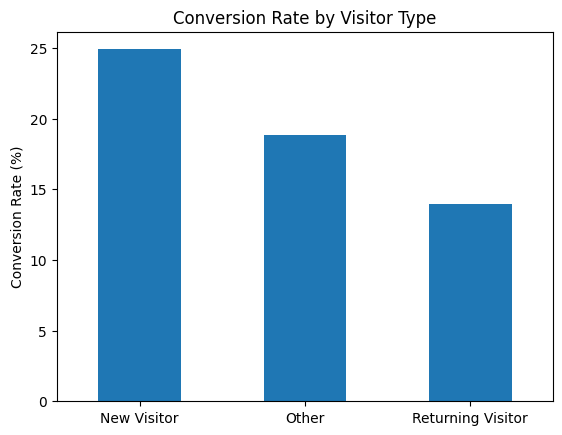

In [22]:
conversion_by_visitor.plot(kind="bar")

plt.title("Conversion Rate by Visitor Type")
plt.xlabel("")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.show()

### 6.4 Conversion Rate by Month

In [23]:
conversion_by_month = (
    df_clean.groupby(["month_number", "month"])["revenue"]
    .mean()
    .mul(100)
    .reset_index()
    .sort_values("month_number")
)

conversion_by_month

,month_number,month,revenue
0,2,Feb,1.630435
1,3,Mar,10.068170
2,5,May,10.850178
3,6,Jun,10.069444
4,7,Jul,15.277778
5,8,Aug,17.551963
6,9,Sep,19.196429
7,10,Oct,20.947177
8,11,Nov,25.350233
9,12,Dec,12.507238


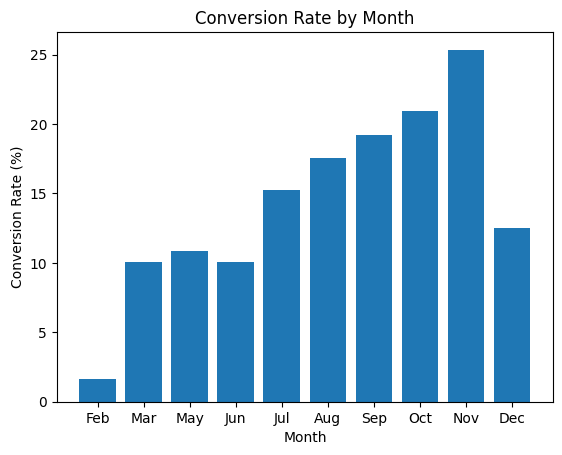

In [24]:
plt.bar(conversion_by_month["month"], conversion_by_month["revenue"])

plt.title("Conversion Rate by Month")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")
plt.show()

### 6.5 Compare Purchase and Non-Purchase Sessions

In [25]:
session_comparison = df_clean.groupby("revenue")[
    [
        "administrative_duration",
        "informational_duration",
        "productrelated_duration",
        "bouncerates",
        "exitrates",
        "pagevalues"
    ]
].mean().round(2)

session_comparison.index = ["No Purchase", "Purchase"]

session_comparison

,administrative_duration,informational_duration,productrelated_duration,bouncerates,exitrates,pagevalues
No Purchase,73.74,30.24,1069.99,0.03,0.05,1.98
Purchase,119.48,57.61,1876.21,0.01,0.02,27.26


## 7. Export the Cleaned Dataset

In [26]:
output_path = project_root / "data" / "processed" / "online_shoppers_cleaned.csv"

df_clean.to_csv(output_path, index=False)

print("Cleaned dataset saved to:", output_path)

Cleaned dataset saved to: /mnt/data/online-shoppers-conversion-analysis-english/data/processed/online_shoppers_cleaned.csv


## 8. Cleaning Summary

- The dataset contains 12,330 sessions.
- No missing values were found.
- No negative numerical values were detected.
- Column names were standardised.
- Text values were made more consistent.
- A `month_number` column was added.
- `weekend` and `revenue` were converted to 0 and 1.
- The 125 identical rows were retained because there is no unique session identifier confirming that they are duplicates.